In [6]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('data/tech_salary_dataset.csv')

In [8]:
import dataframe_image as dfi

In [9]:
df.head()

,employee_id,first_name,last_name,age,gender,location,currency,primary_tech_field,job_title,employment_type,...,monthly_miscellaneous_usd,monthly_total_expenses_usd,annual_total_expenses_usd,annual_savings_usd,vacation_weeks,overtime_hours_per_month,months_since_last_promotion,num_previous_companies,job_satisfaction_score,is_actively_looking
0,EMP-00001,Emma,Johansson,32,Female,Remote (Global),USD,Backend Development,Platform Engineer,Full-time,...,417.44,5175.31,62103.72,6271.69,3,12.9,38,1,6,False
1,EMP-00002,Stephanie,Zhang,30,Female,"Seattle, USA",USD,QA & Testing,QA Engineer,Full-time,...,504.87,10082.84,120994.08,10151.16,4,6.5,26,1,4,False
2,EMP-00003,Raj,Lopez,32,Male,"Amsterdam, Netherlands",EUR,Backend Development,API Engineer,Full-time,...,377.88,8111.78,97341.36,4172.42,5,13.2,0,0,6,True
3,EMP-00004,Amelia,Taylor,31,Female,"London, UK",GBP,Database & Data Engineering,Analytics Engineer,Full-time,...,1140.39,23327.47,279929.64,19102.74,2,5.9,111,5,7,False
4,EMP-00005,Sophia,Gonzalez,42,Female,"Boston, USA",USD,Embedded Systems & IoT,Embedded Engineer,Full-time,...,844.73,11148.58,133782.96,3308.59,6,0.0,20,3,9,False


In [10]:
dfi.export(df.head(10), 'original_df.png', table_conversion='matplotlib', max_cols=-1)

In [11]:
df.columns

Index(['employee_id', 'first_name', 'last_name', 'age', 'gender', 'location',
       'currency', 'primary_tech_field', 'job_title', 'employment_type',
       'work_arrangement', 'experience_years_total',
       'experience_years_in_field', 'education_level', 'languages_spoken',
       'skills', 'primary_skill', 'num_skills', 'certifications',
       'company_size', 'annual_salary_usd', 'monthly_salary_usd',
       'hourly_rate_usd', 'annual_bonus_usd', 'bonus_percentage', 'has_equity',
       'equity_total_value_usd', 'equity_vesting_years',
       'effective_tax_rate_pct', 'annual_tax_usd', 'annual_net_salary_usd',
       'monthly_net_salary_usd', 'monthly_housing_usd',
       'monthly_transportation_usd', 'monthly_food_usd',
       'monthly_utilities_usd', 'monthly_healthcare_usd',
       'monthly_entertainment_usd', 'monthly_education_loan_usd',
       'monthly_childcare_usd', 'monthly_miscellaneous_usd',
       'monthly_total_expenses_usd', 'annual_total_expenses_usd',
       'annu

Lots of columns, let's clean this up and only keep what I need

In [12]:
df = df.drop(df.loc[:, 'monthly_net_salary_usd':'annual_savings_usd'], axis=1)
df = df.drop(df.loc[:, 'first_name':'last_name'], axis=1)
df = df.drop('work_arrangement', axis=1)
df = df.drop('employee_id', axis=1)
df = df.drop(df.loc[:, 'annual_salary_usd':'annual_tax_usd'], axis=1)
df = df.drop(df.loc[:, 'vacation_weeks':'num_previous_companies'], axis=1)

In [13]:
df.columns

Index(['age', 'gender', 'location', 'currency', 'primary_tech_field',
       'job_title', 'employment_type', 'experience_years_total',
       'experience_years_in_field', 'education_level', 'languages_spoken',
       'skills', 'primary_skill', 'num_skills', 'certifications',
       'company_size', 'annual_net_salary_usd', 'job_satisfaction_score',
       'is_actively_looking'],
      dtype='object')

This is good for now, I will probably take some more out later. But now I want to isolate only jobs that pay in USD.

In [14]:
df['currency'].unique()

array(['USD', 'EUR', 'GBP', 'AUD', 'JPY', 'KRW', 'SGD', 'INR', 'ILS',
       'CAD'], dtype=object)

In [15]:
df = df[df['currency']=='USD']

In [16]:
important_columns = df[['skills', 'annual_net_salary_usd', 'experience_years_total', 'location', 'education_level', 'primary_tech_field', 'company_size']]
important_columns

,skills,annual_net_salary_usd,experience_years_total,location,education_level,primary_tech_field,company_size
0,Spring Boot; PHP; Python,76931.18,7.7,Remote (Global),Associate's Degree,Backend Development,Small (11-50)
1,PyTest; API Testing; Cypress; JUnit; Postman; ...,69003.22,3.0,"Seattle, USA",Bootcamp,QA & Testing,Startup (1-10)
4,RTOS; ARM; PCB Design; Embedded Linux,105042.46,7.9,"Boston, USA",Bootcamp,Embedded Systems & IoT,Startup (1-10)
5,Maya; Photon; Blender,112888.66,9.8,"San Francisco, USA",Bachelor's Degree,Game Development,Small (11-50)
6,CI/CD; Go; Linux; Terraform; Incident Manageme...,95907.92,0.5,"New York, USA",Bachelor's Degree,Site Reliability Engineering,Medium (51-200)
...,...,...,...,...,...,...,...
9987,Xcode; Flutter; React Native; Kotlin; Android SDK,81479.86,0.5,"New York, USA",Master's Degree,Mobile Development,Large (201-1000)
9990,Python; Django; Spring Boot; Go; Express.js; C...,86802.15,1.8,"Boston, USA",Bachelor's Degree,Backend Development,Startup (1-10)
9993,Pandas; PyTorch; Python; scikit-learn,164241.72,8.1,"Seattle, USA",High School,Data Science & ML,Medium (51-200)
9996,GraphQL; Python; Vue.js; REST APIs; Docker; Mo...,127348.17,9.7,"Boston, USA",Bootcamp,Full-Stack Development,Small (11-50)


Because I dropped rows, I need to reset my index if I need to reference a row by its position or join any dfs or derivative dfs

In [62]:
important_columns = important_columns.reset_index(drop=True)

In [63]:
important_columns

,skills,annual_net_salary_usd,experience_years_total,location,education_level,primary_tech_field,company_size
0,Spring Boot; PHP; Python,76931.18,7.7,Remote (Global),Associate's Degree,Backend Development,Small (11-50)
1,PyTest; API Testing; Cypress; JUnit; Postman; ...,69003.22,3.0,"Seattle, USA",Bootcamp,QA & Testing,Startup (1-10)
2,RTOS; ARM; PCB Design; Embedded Linux,105042.46,7.9,"Boston, USA",Bootcamp,Embedded Systems & IoT,Startup (1-10)
3,Maya; Photon; Blender,112888.66,9.8,"San Francisco, USA",Bachelor's Degree,Game Development,Small (11-50)
4,CI/CD; Go; Linux; Terraform; Incident Manageme...,95907.92,0.5,"New York, USA",Bachelor's Degree,Site Reliability Engineering,Medium (51-200)
...,...,...,...,...,...,...,...
5412,Xcode; Flutter; React Native; Kotlin; Android SDK,81479.86,0.5,"New York, USA",Master's Degree,Mobile Development,Large (201-1000)
5413,Python; Django; Spring Boot; Go; Express.js; C...,86802.15,1.8,"Boston, USA",Bachelor's Degree,Backend Development,Startup (1-10)
5414,Pandas; PyTorch; Python; scikit-learn,164241.72,8.1,"Seattle, USA",High School,Data Science & ML,Medium (51-200)
5415,GraphQL; Python; Vue.js; REST APIs; Docker; Mo...,127348.17,9.7,"Boston, USA",Bootcamp,Full-Stack Development,Small (11-50)


In [56]:
dfi.export(important_columns.head(10), 'filtered_df.png', table_conversion='matplotlib', max_cols=-1)

What does the skills column really look like?

In [52]:
important_columns.loc[:]['skills']

0                                Spring Boot; PHP; Python
1       PyTest; API Testing; Cypress; JUnit; Postman; ...
4                   RTOS; ARM; PCB Design; Embedded Linux
5                                   Maya; Photon; Blender
6       CI/CD; Go; Linux; Terraform; Incident Manageme...
                              ...                        
9987    Xcode; Flutter; React Native; Kotlin; Android SDK
9990    Python; Django; Spring Boot; Go; Express.js; C...
9993                Pandas; PyTorch; Python; scikit-learn
9996    GraphQL; Python; Vue.js; REST APIs; Docker; Mo...
9998    OpenCV; SQL; Keras; Python; R; PyTorch; scikit...
Name: skills, Length: 5417, dtype: object

Looks like these are lists of proficiencies. Let's separate them so we can calculate based on individual skills and create dummy variables

In [53]:
skills = important_columns['skills'].str.get_dummies(';')
with pd.option_context('display.max_seq_items', None):
    print(skills.columns)

Index([' 3D Modeling', ' A/B Testing', ' API Testing', ' ARM', ' AWS',
       ' Agile', ' Airflow', ' Android SDK', ' Angular', ' Ansible', ' Azure',
       ' BigQuery', ' Blender', ' Burp Suite', ' C', ' C#', ' C++', ' CI/CD',
       ' Cassandra', ' Confluence', ' Cryptography', ' Cypress', ' Dart',
       ' Data Analysis', ' DeFi', ' DirectX', ' Django', ' Docker',
       ' Elasticsearch', ' Embedded Linux', ' Ethereum', ' Ethical Hacking',
       ' Express.js', ' FPGA', ' FastAPI', ' Figma', ' Firebase', ' Firewalls',
       ' Flutter', ' Foundry', ' GCP', ' Go', ' Grafana', ' GraphQL',
       ' HTML/CSS', ' Hardhat', ' Helm', ' Hugging Face', ' I2C/SPI',
       ' IDS/IPS', ' IPFS', ' Incident Management', ' Incident Response',
       ' JUnit', ' Java', ' JavaScript', ' Jenkins', ' Jest',
       ' Jetpack Compose', ' Jira', ' Kafka', ' Keras', ' Kotlin',
       ' Kubernetes', ' Linux', ' Load Testing', ' MATLAB', ' MQTT', ' Maya',
       ' Microcontrollers', ' MongoDB', ' NLTK', ' N

Looks like I have a formatting issue where the skills were separated not only by ";" but also " "

In [54]:
skills.columns = skills.columns.str.strip()
with pd.option_context('display.max_seq_items', None):
    print(skills.columns)

Index(['3D Modeling', 'A/B Testing', 'API Testing', 'ARM', 'AWS', 'Agile',
       'Airflow', 'Android SDK', 'Angular', 'Ansible', 'Azure', 'BigQuery',
       'Blender', 'Burp Suite', 'C', 'C#', 'C++', 'CI/CD', 'Cassandra',
       'Confluence', 'Cryptography', 'Cypress', 'Dart', 'Data Analysis',
       'DeFi', 'DirectX', 'Django', 'Docker', 'Elasticsearch',
       'Embedded Linux', 'Ethereum', 'Ethical Hacking', 'Express.js', 'FPGA',
       'FastAPI', 'Figma', 'Firebase', 'Firewalls', 'Flutter', 'Foundry',
       'GCP', 'Go', 'Grafana', 'GraphQL', 'HTML/CSS', 'Hardhat', 'Helm',
       'Hugging Face', 'I2C/SPI', 'IDS/IPS', 'IPFS', 'Incident Management',
       'Incident Response', 'JUnit', 'Java', 'JavaScript', 'Jenkins', 'Jest',
       'Jetpack Compose', 'Jira', 'Kafka', 'Keras', 'Kotlin', 'Kubernetes',
       'Linux', 'Load Testing', 'MATLAB', 'MQTT', 'Maya', 'Microcontrollers',
       'MongoDB', 'NLTK', 'Network Security', 'Next.js', 'Nmap', 'Node.js',
       'Objective-C', 'OpenCV', 

In [22]:
skills = skills.groupby(skills.columns, axis=1).max()
with pd.option_context('display.max_seq_items', None):
    print(skills.columns)

Index(['3D Modeling', 'A/B Testing', 'API Testing', 'ARM', 'AWS', 'Agile',
       'Airflow', 'Android SDK', 'Angular', 'Ansible', 'Azure', 'BigQuery',
       'Blender', 'Burp Suite', 'C', 'C#', 'C++', 'CI/CD', 'Cassandra',
       'Confluence', 'Cryptography', 'Cypress', 'Dart', 'Data Analysis',
       'DeFi', 'DirectX', 'Django', 'Docker', 'Elasticsearch',
       'Embedded Linux', 'Ethereum', 'Ethical Hacking', 'Express.js', 'FPGA',
       'FastAPI', 'Figma', 'Firebase', 'Firewalls', 'Flutter', 'Foundry',
       'GCP', 'Go', 'Grafana', 'GraphQL', 'HTML/CSS', 'Hardhat', 'Helm',
       'Hugging Face', 'I2C/SPI', 'IDS/IPS', 'IPFS', 'Incident Management',
       'Incident Response', 'JUnit', 'Java', 'JavaScript', 'Jenkins', 'Jest',
       'Jetpack Compose', 'Jira', 'Kafka', 'Keras', 'Kotlin', 'Kubernetes',
       'Linux', 'Load Testing', 'MATLAB', 'MQTT', 'Maya', 'Microcontrollers',
       'MongoDB', 'NLTK', 'Network Security', 'Next.js', 'Nmap', 'Node.js',
       'Objective-C', 'OpenCV', 

/var/folders/6q/gcvrft1x6vqd8ns1bjj5cz6w0000gn/T/ipykernel_92856/1180687828.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  skills = skills.groupby(skills.columns, axis=1).max()


In [57]:
skills

,3D Modeling,A/B Testing,API Testing,ARM,AWS,Agile,Airflow,Android SDK,Angular,Ansible,...,User Research,Vue.js,Web3.js,Webpack,Wireframing,Wireshark,Xcode,dbt,ethers.js,scikit-learn
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9987,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
9990,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9993,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [58]:
dfi.export(skills.head(10), 'skills_df.png', table_conversion='matplotlib', max_cols=-1)

Skills dummy df cleaned!

In [60]:
columns_to_check = ['experience_years_total', 'location', 'education_level', 'primary_tech_field', 'company_size', 'annual_net_salary_usd']
df_clean = df.dropna(subset=columns_to_check).copy()
df_clean

,age,gender,location,currency,primary_tech_field,job_title,employment_type,experience_years_total,experience_years_in_field,education_level,languages_spoken,skills,primary_skill,num_skills,certifications,company_size,annual_net_salary_usd,job_satisfaction_score,is_actively_looking
0,32,Female,Remote (Global),USD,Backend Development,Platform Engineer,Full-time,7.7,3.2,Associate's Degree,English,Spring Boot; PHP; Python,Spring Boot,3,NaN,Small (11-50),76931.18,6,False
1,30,Female,"Seattle, USA",USD,QA & Testing,QA Engineer,Full-time,3.0,1.9,Bootcamp,English; Telugu,PyTest; API Testing; Cypress; JUnit; Postman; ...,PyTest,8,NaN,Startup (1-10),69003.22,4,False
2,42,Female,"Boston, USA",USD,Embedded Systems & IoT,Embedded Engineer,Full-time,7.9,3.8,Bootcamp,English; Telugu,RTOS; ARM; PCB Design; Embedded Linux,RTOS,4,NaN,Startup (1-10),105042.46,9,False
3,28,Male,"San Francisco, USA",USD,Game Development,Game Developer,Full-time,9.8,4.3,Bachelor's Degree,English,Maya; Photon; Blender,Maya,3,Google Cloud Professional,Small (11-50),112888.66,3,False
4,29,Male,"New York, USA",USD,Site Reliability Engineering,SRE,Full-time,0.5,0.5,Bachelor's Degree,English; Arabic,CI/CD; Go; Linux; Terraform; Incident Manageme...,CI/CD,8,NaN,Medium (51-200),95907.92,10,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5412,34,Female,"New York, USA",USD,Mobile Development,React Native Developer,Full-time,0.5,0.5,Master's Degree,English; Italian,Xcode; Flutter; React Native; Kotlin; Android SDK,Xcode,5,NaN,Large (201-1000),81479.86,3,False
5413,40,Male,"Boston, USA",USD,Backend Development,Backend Developer,Full-time,1.8,1.1,Bachelor's Degree,English,Python; Django; Spring Boot; Go; Express.js; C...,Python,7,Linux Foundation Certified,Startup (1-10),86802.15,8,False
5414,28,Non-Binary,"Seattle, USA",USD,Data Science & ML,NLP Engineer,Contract,8.1,6.3,High School,English; French,Pandas; PyTorch; Python; scikit-learn,Pandas,4,NaN,Medium (51-200),164241.72,8,False
5415,37,Male,"Boston, USA",USD,Full-Stack Development,Full Stack Developer,Full-time,9.7,7.0,Bootcamp,English,GraphQL; Python; Vue.js; REST APIs; Docker; Mo...,GraphQL,6,Certified Scrum Master; Azure Solutions Architect,Small (11-50),127348.17,9,False


In [24]:
skills_clean = skills.loc[df_clean.index].reset_index(drop=True)
df_clean = df_clean.reset_index(drop=True)
df_clean

,age,gender,location,currency,primary_tech_field,job_title,employment_type,experience_years_total,experience_years_in_field,education_level,languages_spoken,skills,primary_skill,num_skills,certifications,company_size,annual_net_salary_usd,job_satisfaction_score,is_actively_looking
0,32,Female,Remote (Global),USD,Backend Development,Platform Engineer,Full-time,7.7,3.2,Associate's Degree,English,Spring Boot; PHP; Python,Spring Boot,3,NaN,Small (11-50),76931.18,6,False
1,30,Female,"Seattle, USA",USD,QA & Testing,QA Engineer,Full-time,3.0,1.9,Bootcamp,English; Telugu,PyTest; API Testing; Cypress; JUnit; Postman; ...,PyTest,8,NaN,Startup (1-10),69003.22,4,False
2,42,Female,"Boston, USA",USD,Embedded Systems & IoT,Embedded Engineer,Full-time,7.9,3.8,Bootcamp,English; Telugu,RTOS; ARM; PCB Design; Embedded Linux,RTOS,4,NaN,Startup (1-10),105042.46,9,False
3,28,Male,"San Francisco, USA",USD,Game Development,Game Developer,Full-time,9.8,4.3,Bachelor's Degree,English,Maya; Photon; Blender,Maya,3,Google Cloud Professional,Small (11-50),112888.66,3,False
4,29,Male,"New York, USA",USD,Site Reliability Engineering,SRE,Full-time,0.5,0.5,Bachelor's Degree,English; Arabic,CI/CD; Go; Linux; Terraform; Incident Manageme...,CI/CD,8,NaN,Medium (51-200),95907.92,10,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5412,34,Female,"New York, USA",USD,Mobile Development,React Native Developer,Full-time,0.5,0.5,Master's Degree,English; Italian,Xcode; Flutter; React Native; Kotlin; Android SDK,Xcode,5,NaN,Large (201-1000),81479.86,3,False
5413,40,Male,"Boston, USA",USD,Backend Development,Backend Developer,Full-time,1.8,1.1,Bachelor's Degree,English,Python; Django; Spring Boot; Go; Express.js; C...,Python,7,Linux Foundation Certified,Startup (1-10),86802.15,8,False
5414,28,Non-Binary,"Seattle, USA",USD,Data Science & ML,NLP Engineer,Contract,8.1,6.3,High School,English; French,Pandas; PyTorch; Python; scikit-learn,Pandas,4,NaN,Medium (51-200),164241.72,8,False
5415,37,Male,"Boston, USA",USD,Full-Stack Development,Full Stack Developer,Full-time,9.7,7.0,Bootcamp,English,GraphQL; Python; Vue.js; REST APIs; Docker; Mo...,GraphQL,6,Certified Scrum Master; Azure Solutions Architect,Small (11-50),127348.17,9,False


In [25]:
dummy = pd.get_dummies(df_clean[['experience_years_total', 'location', 'education_level', 'primary_tech_field', 'company_size']], drop_first=True, dtype=int)
dummy = dummy.reset_index(drop=True)
skills_clean = skills_clean.reset_index(drop=True)
x = pd.concat([dummy, skills_clean], axis=1)
y = df_clean['annual_net_salary_usd']

In [26]:
mod = LinearRegression()
mod.fit(x,y)
controlled = pd.Series(mod.coef_, index=x.columns).sort_values(ascending=False)
controlled


education_level_PhD                     53303.029167
location_San Francisco, USA             44761.601347
education_level_Master's Degree         38089.549238
primary_tech_field_Blockchain & Web3    36718.753719
primary_tech_field_Data Science & ML    36460.210368
                                            ...     
primary_tech_field_Game Development    -23211.289231
company_size_Medium (51-200)           -26211.364639
primary_tech_field_QA & Testing        -27435.446465
company_size_Small (11-50)             -37651.091942
company_size_Startup (1-10)            -43017.499992
Length: 163, dtype: float64

In [27]:
mod.score(x,y)

0.8595448532676838

In [28]:
skill_bump = controlled.loc[skills_clean.columns]
skill_bump = skill_bump.sort_values(ascending=False)
print(skill_bump.head(10))
print(skill_bump.tail(10))

Smart Contracts       7431.830499
Blender               6321.272166
ethers.js             5838.763030
TestRail              4568.734694
Shader Programming    4058.118144
C                     3438.008242
MATLAB                3339.806139
Airflow               3309.834191
Snowflake             3229.423138
Hardhat               2675.959357
dtype: float64
Cypress            -2769.522003
PostgreSQL         -3118.428615
CI/CD              -3148.194137
dbt                -3182.541044
JavaScript         -3393.139497
GCP                -3421.572650
Network Security   -3436.273966
OpenGL             -3615.434798
Roadmapping        -3630.851127
Foundry            -4657.727993
dtype: float64


In [29]:
controlled_factors = controlled.drop(skills.columns)
controlled_factors = controlled_factors.sort_values(ascending=False)
controlled_factors

education_level_PhD                                53303.029167
location_San Francisco, USA                        44761.601347
education_level_Master's Degree                    38089.549238
primary_tech_field_Blockchain & Web3               36718.753719
primary_tech_field_Data Science & ML               36460.210368
location_New York, USA                             32657.210242
location_Seattle, USA                              25779.100935
primary_tech_field_Product Management              24143.989861
primary_tech_field_Site Reliability Engineering    23041.314969
location_Boston, USA                               19440.274719
primary_tech_field_Cybersecurity                   17080.883846
primary_tech_field_DevOps & Cloud                  16181.842962
education_level_Bachelor's Degree                  14925.613340
primary_tech_field_Database & Data Engineering     11440.818103
primary_tech_field_Full-Stack Development           8363.854593
location_Miami, USA                     

Controlling for the relevant variables in the dataset, it looks like having a PhD, working in San Francisco, and being in blockchain and web3 are correlated with the highest increase in salary.

Text(0, 0.5, 'Skill Name')

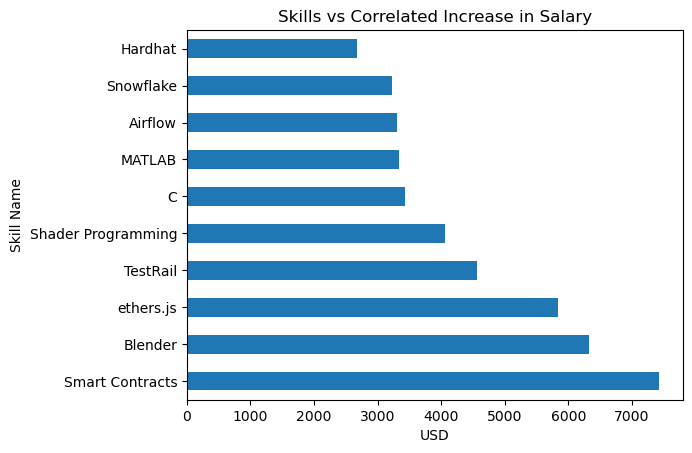

In [30]:
skill_bump.head(10).plot(kind='barh')
plt.title('Skills vs Correlated Increase in Salary')
plt.xlabel('USD')
plt.ylabel('Skill Name')

Text(0, 0.5, 'Skill Name')

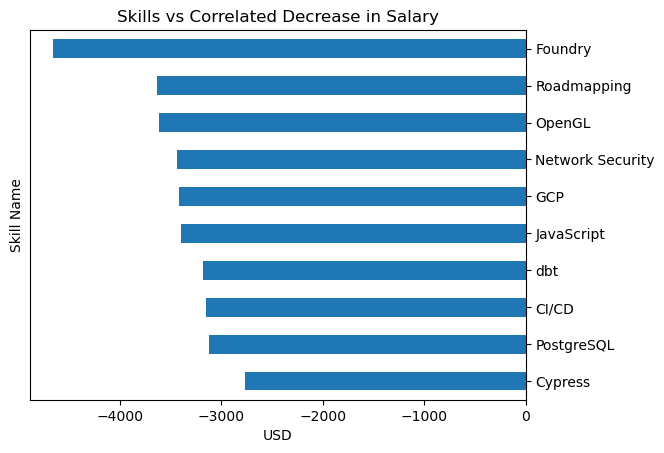

In [31]:
fig = skill_bump.tail(10).plot(kind='barh')
fig.yaxis.tick_right()
plt.title('Skills vs Correlated Decrease in Salary')
plt.xlabel('USD')
plt.ylabel('Skill Name')

Text(0, 0.5, 'Factor')

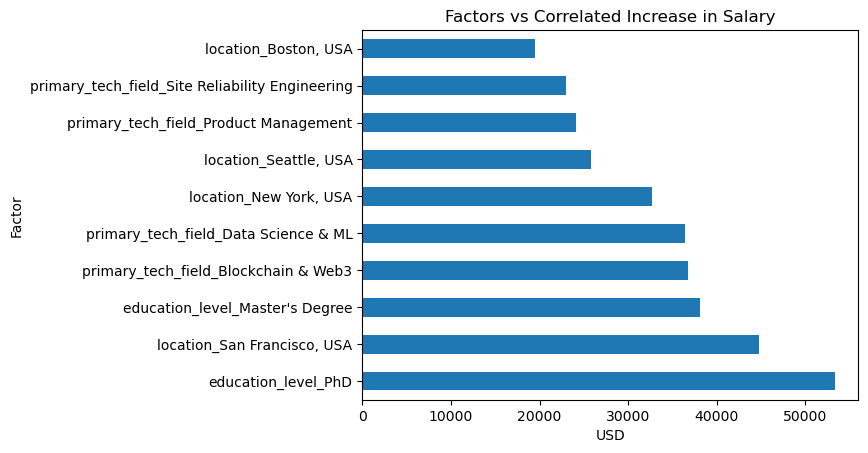

In [32]:
controlled_factors.head(10).plot(kind='barh')
plt.title('Factors vs Correlated Increase in Salary')
plt.xlabel('USD')
plt.ylabel('Factor')

Text(0, 0.5, 'Factor')

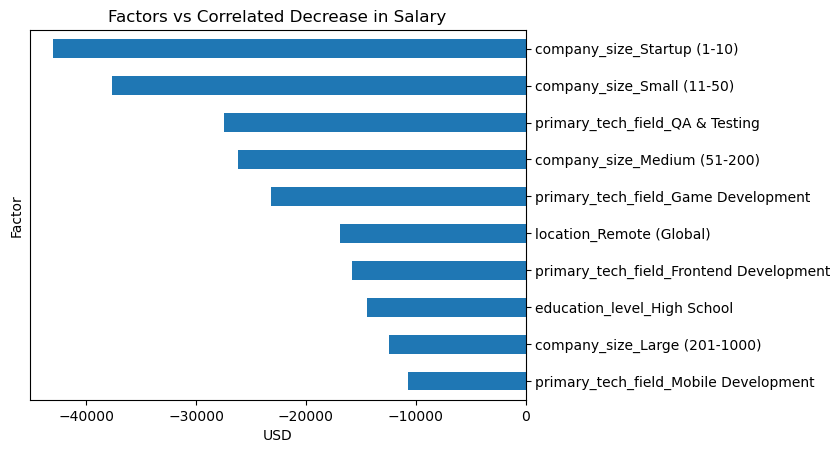

In [33]:
fig = controlled_factors.tail(10).plot(kind='barh')
fig.yaxis.tick_right()
plt.title('Factors vs Correlated Decrease in Salary')
plt.xlabel('USD')
plt.ylabel('Factor')

In [34]:
df['location'].dropna().sort_values().unique()

array(['Austin, USA', 'Boston, USA', 'Denver, USA', 'Miami, USA',
       'New York, USA', 'Remote (Global)', 'San Francisco, USA',
       'Seattle, USA'], dtype=object)

In [35]:
[col for col in dummy.columns if col.startswith('location_')]

['location_Boston, USA',
 'location_Denver, USA',
 'location_Miami, USA',
 'location_New York, USA',
 'location_Remote (Global)',
 'location_San Francisco, USA',
 'location_Seattle, USA']

Location baseline is Austin

In [36]:
df['experience_years_total'].dropna().sort_values().unique()

array([ 0.5,  0.6,  0.7,  0.8,  0.9,  1. ,  1.1,  1.2,  1.3,  1.4,  1.5,
        1.6,  1.7,  1.8,  1.9,  2. ,  2.1,  2.2,  2.3,  2.4,  2.5,  2.6,
        2.7,  2.8,  2.9,  3. ,  3.1,  3.2,  3.3,  3.4,  3.5,  3.6,  3.7,
        3.8,  3.9,  4. ,  4.1,  4.2,  4.3,  4.4,  4.5,  4.6,  4.7,  4.8,
        4.9,  5. ,  5.1,  5.2,  5.3,  5.4,  5.5,  5.6,  5.7,  5.8,  5.9,
        6. ,  6.1,  6.2,  6.3,  6.4,  6.5,  6.6,  6.7,  6.8,  6.9,  7. ,
        7.1,  7.2,  7.3,  7.4,  7.5,  7.6,  7.7,  7.8,  7.9,  8. ,  8.1,
        8.2,  8.3,  8.4,  8.5,  8.6,  8.7,  8.8,  8.9,  9. ,  9.1,  9.2,
        9.3,  9.4,  9.5,  9.6,  9.7,  9.8,  9.9, 10. , 10.1, 10.2, 10.3,
       10.4, 10.5, 10.6, 10.7, 10.8, 10.9, 11. , 11.1, 11.2, 11.3, 11.4,
       11.5, 11.6, 11.7, 11.8, 11.9, 12. , 12.1, 12.2, 12.3, 12.4, 12.5,
       12.6, 12.7, 12.8, 12.9, 13. , 13.1, 13.2, 13.3, 13.4, 13.5, 13.6,
       13.7, 13.8, 13.9, 14. , 14.1, 14.2, 14.3, 14.4, 14.5, 14.6, 14.7,
       14.8, 14.9, 15. , 15.1, 15.2, 15.3, 15.4, 15

In [37]:
[col for col in x.columns if 'experience_years_total' in col]

['experience_years_total']

This is fine because it means that making variables didn't make each experience year it's own category

In [38]:
df['education_level'].sort_values().unique()

array(["Associate's Degree", "Bachelor's Degree", 'Bootcamp',
       'High School', "Master's Degree", 'PhD'], dtype=object)

In [39]:
[col for col in x.columns if 'education_level' in col]

["education_level_Bachelor's Degree",
 'education_level_Bootcamp',
 'education_level_High School',
 "education_level_Master's Degree",
 'education_level_PhD']

In [40]:
controlled[controlled.index.str.contains('education_level')]

education_level_PhD                  53303.029167
education_level_Master's Degree      38089.549238
education_level_Bachelor's Degree    14925.613340
education_level_Bootcamp               618.180737
education_level_High School         -14456.031553
dtype: float64

Baseline for education level is Associate's degree

In [41]:
df['primary_tech_field'].sort_values().unique()

array(['Backend Development', 'Blockchain & Web3', 'Cybersecurity',
       'Data Science & ML', 'Database & Data Engineering',
       'DevOps & Cloud', 'Embedded Systems & IoT', 'Frontend Development',
       'Full-Stack Development', 'Game Development', 'Mobile Development',
       'Product Management', 'QA & Testing',
       'Site Reliability Engineering'], dtype=object)

In [42]:
[col for col in x.columns if 'primary_tech_field' in col]

['primary_tech_field_Blockchain & Web3',
 'primary_tech_field_Cybersecurity',
 'primary_tech_field_Data Science & ML',
 'primary_tech_field_Database & Data Engineering',
 'primary_tech_field_DevOps & Cloud',
 'primary_tech_field_Embedded Systems & IoT',
 'primary_tech_field_Frontend Development',
 'primary_tech_field_Full-Stack Development',
 'primary_tech_field_Game Development',
 'primary_tech_field_Mobile Development',
 'primary_tech_field_Product Management',
 'primary_tech_field_QA & Testing',
 'primary_tech_field_Site Reliability Engineering']

In [43]:
df.groupby('primary_tech_field')['annual_net_salary_usd'].mean().sort_values(ascending=False)

primary_tech_field
Blockchain & Web3               169104.466281
Data Science & ML               164492.698100
Product Management              154848.474851
DevOps & Cloud                  152126.438957
Site Reliability Engineering    151623.722556
Cybersecurity                   147762.487176
Database & Data Engineering     141860.518671
Full-Stack Development          141000.859631
Backend Development             134265.267748
Embedded Systems & IoT          131166.051528
Mobile Development              123329.105772
Frontend Development            115440.172300
Game Development                109064.146239
QA & Testing                    102662.465411
Name: annual_net_salary_usd, dtype: float64

In [44]:
controlled[controlled.index.str.contains('primary_tech_field')]

primary_tech_field_Blockchain & Web3               36718.753719
primary_tech_field_Data Science & ML               36460.210368
primary_tech_field_Product Management              24143.989861
primary_tech_field_Site Reliability Engineering    23041.314969
primary_tech_field_Cybersecurity                   17080.883846
primary_tech_field_DevOps & Cloud                  16181.842962
primary_tech_field_Database & Data Engineering     11440.818103
primary_tech_field_Full-Stack Development           8363.854593
primary_tech_field_Embedded Systems & IoT          -7390.732988
primary_tech_field_Mobile Development             -10681.589898
primary_tech_field_Frontend Development           -15791.932465
primary_tech_field_Game Development               -23211.289231
primary_tech_field_QA & Testing                   -27435.446465
dtype: float64

Baseline is backend development. Looks like it isn't at the bottom, so negative values just mean that backend development is the baseline for salaries.

In [45]:
df['company_size'].sort_values().unique()

array(['Enterprise (1000+)', 'Large (201-1000)', 'Medium (51-200)',
       'Small (11-50)', 'Startup (1-10)'], dtype=object)

In [46]:
[col for col in x.columns if 'company_size' in col]

['company_size_Large (201-1000)',
 'company_size_Medium (51-200)',
 'company_size_Small (11-50)',
 'company_size_Startup (1-10)']

In [47]:
controlled[controlled.index.str.contains('company_size')]

company_size_Large (201-1000)   -12411.149218
company_size_Medium (51-200)    -26211.364639
company_size_Small (11-50)      -37651.091942
company_size_Startup (1-10)     -43017.499992
dtype: float64

Enterprise is the baseline for salary. Looks like it is one of the extreme values so we have a clear baseline.

The reason I am not checking for skills is because not dropping them would not necessarily lead to perfect multicollinearity. Skills are not mutually exclusive since people may have more than one skill.

I realize that some of these skills are not very common. I want to filter for skills that have more than 50 occurrences out of the 5417 rows I kept 

In [48]:
skills_clean.sum()

3D Modeling     103
A/B Testing     205
API Testing     158
ARM             117
AWS             630
               ... 
Wireshark       126
Xcode           169
dbt             130
ethers.js        82
scikit-learn    272
Length: 133, dtype: int64

In [49]:
skill_sum = skills_clean.sum()
common_skills = skill_sum[skill_sum > 0]
common_skills

3D Modeling     103
A/B Testing     205
API Testing     158
ARM             117
AWS             630
               ... 
Wireshark       126
Xcode           169
dbt             130
ethers.js        82
scikit-learn    272
Length: 133, dtype: int64

Looks like all skills appear in at least 1% of people in the data. I think that is fine for the analysis I am conducting

In [50]:
skill_bump.loc[common_skills.index].sort_values(ascending=False).head(10)


Smart Contracts       7431.830499
Blender               6321.272166
ethers.js             5838.763030
TestRail              4568.734694
Shader Programming    4058.118144
C                     3438.008242
MATLAB                3339.806139
Airflow               3309.834191
Snowflake             3229.423138
Hardhat               2675.959357
dtype: float64

In [51]:
metrics = pd.DataFrame({'pay': skill_bump.loc[common_skills.index], 'count': skill_sum.loc[common_skills.index]})
metrics = metrics[metrics['pay'] > 0]
metrics['value_score'] = metrics['pay'] * metrics['count']
top_skills = metrics.sort_values(by='value_score', ascending=False)
top_skills.head(20)

,pay,count,value_score
Docker,1243.263055,630,783255.724544
Blender,6321.272166,107,676376.121794
TestRail,4568.734694,147,671603.999988
Smart Contracts,7431.830499,86,639137.422901
Airflow,3309.834191,146,483235.791903
GraphQL,899.024224,536,481876.984237
ethers.js,5838.763030,82,478778.568450
Snowflake,3229.423138,146,471495.778128
Redux,1929.685713,244,470843.313955
PHP,1907.289875,243,463471.439680
